In [552]:
import sys
from pathlib import Path
import tqdm.notebook as tqdm 
import numpy as np
import yaml
import jax

ROOT = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths")
CFG = ROOT / "config" / "config_phonons.yaml"


import EI.ei_unified as eu
from phase_map_plots import plot_maps, scan_maps
from fixed_baths import (
    plot_bz,
    plot_dispersion,
    plot_energy,
    plot_xi,
    solve_state,
    solve_teff,
)
from utils.cosmetics import apply_plt_style
from utils.logger import logger
from utils.plotting_utils import Plotter
import EI.ei_unified as eu
import EI.ei_jax_2 as ej
import EI.ei_phonon as pb

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, plot_cmap, format_ax, add_legend, plot_cmap, plot_phase_diag, color_map
from fixed_baths import k_path, take_path, color_line, solve_state, plot_dispersion


apply_plt_style()
pt = Plotter(show=True, close=False)

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [553]:
import matplotlib.pyplot as plt
import colormaps as cmaps
import jax.numpy as jnp
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
from utils.cosmetics import SET1_LIST

In [554]:
with CFG.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]
nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)
p = eu.MFPars(**md["mean_field"])

In [555]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])
d0 = max(abs(float(s0.d)), 1.0e-12)
m0 = float(s0.m)
tc = float(eu.critical_temperature(bd_ref, p, **eq["critical"]))

logger.info("Delta_0 = %.8f", d0)
logger.info("m_0 = %.8f", m0)
logger.info("T_c = %.8f", tc)

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[17:30:49] [INFO    ] Delta_0 = 1.00005168
[17:30:49] [INFO    ] m_0 = -0.68433834
[17:30:49] [INFO    ] T_c = 0.53523542


In [556]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

st = ej.mf_state(bd_ref, p, s0.d, s0.m)
t1n, t2n = 1.0, 0.2
t1, t2 = t1n * tc, t2n * tc

In [557]:
bc = op["bath"]
fn = getattr(pb, bc["rate"])
bp = dict(bc["pars"])

bs =(
    fn(t1, bd.k, name=f"bath_1", **bp),
    fn(t2, bd.k, name=f"bath_1", **bp))

es = {**eq["solve"], "prog": False}
se = eu.solve_eq(
    bd, p,
    t=t2,
    d=max(abs(d0), 1.0e-8),
    m=m0,
    **es,
)

sk = {
    "mix": (1.0, 1.0, 1.0),
    "tol": 1.0e-5,
    "nmax": 20000,
    "chk": 100,
    "prog": True,
}

so = ej.solve_fixed(
    bd, p, se.n.copy(), bs,
    d=float(se.d),
    m=float(se.m),
    **sk,
)

st = ej.mf_state(
    bd, p,
    d=float(so.d),
    m=float(so.m),
)


Fixed EI JAX:   0%|          | 0/200 [00:00<?, ?it/s]

In [558]:
# def t_star0(w0, ta, tb):
#     """Sharp-line T*(w0) for two identical baths at ta, tb."""
#     nm = 0.5 * (1.0 / np.expm1(w0 / ta) + 1.0 / np.expm1(w0 / tb))
#     return w0 / np.log1p(1.0 / nm)


# def ness_point(nq, bq):
#     """NESS and equilibrium references on an nq x nq grid for bath pars bq."""
#     bg = eu.tb_2d(nq, **md["band"]["pars"])
#     bb = tuple(fn(t, bg.k, name=f"bath_{i + 1}", **bq) for i, t in enumerate((t1, t2)))
#     s2 = eu.solve_eq(bg, p, t=t2, d=max(abs(d0), 1.0e-8), m=m0, **es)
#     sn = ej.solve_fixed(bg, p, s2.n.copy(), bb, d=float(s2.d), m=float(s2.m),
#                         **{**sk, "prog": False})
#     ts = t_star0(bq.get("w0", 1.0), t1, t2)
#     se_ = eu.solve_eq(bg, p, t=ts, d=max(abs(d0), 1.0e-8), m=m0, **es)
#     return dict(d=abs(sn.d), m=sn.m, ok=sn.ok, err=sn.err,
#                 de=abs(se_.d), me=se_.m, ts=ts)


# def run_sweep(xs, fq):
#     """Evaluate ness_point for each x; fq(x) -> (nq, bath pars)."""
#     rs = [ness_point(*fq(x)) for x in tqdm.tqdm(xs, desc="sweep")]
#     return {q: np.array([r[q] for r in rs]) for q in rs[0]}


# def plot_sweep(xs, zs, xlabel):
#     """Delta/Delta0 and m of the NESS vs eq(T*) on one panel."""
#     with pt.figure(h=0.65) as fg:
#         a = fg.ax
#         a.plot(xs, zs["d"] / d0, "-o", color=SET1_LIST[0], ms=3, lw=1.2,
#                label=r"$\Delta/\Delta_0$ NESS")
#         a.plot(xs, zs["de"] / d0, "--", color=SET1_LIST[1], lw=1.0,
#                label=r"$\Delta/\Delta_0$ eq. $T^*$")
#         # a.plot(xs, zs["m"], "-s", color=SET1_LIST[1], ms=3, lw=1.2,
#         #        label=r"$m$ NESS")
#         # a.plot(xs, zs["me"], "--", color=SET1_LIST[1], lw=1.0,
#         #        label=r"$m$ eq. $T^*$")
#         bad = ~zs["ok"]
#         if bad.any():
#             a.scatter(xs[bad], zs["d"][bad] / d0, marker="x", color="k", s=20,
#                       zorder=5)
#         format_ax(a, x=xs, xlabel=xlabel, ylabel=r"$\Delta/\Delta_0$")
#         add_legend(a, top=True, ncol=2, fontsize=7)
#         fg.layout((0, 0, 1, 0.82))


# es = {**eq["solve"], "prog": False}
# bp0 = dict(op["bath"]["pars"])

# nks = np.r_[np.arange(15, 60, 4), 60]
# # zk = run_sweep(nks, lambda n: (int(n), bp0))
# # plot_sweep(nks.astype(float), zk, r"$N_k$")

# ews = np.linspace(0.1, 1.0, 10)
# zw = run_sweep(ews, lambda e: (60, {**bp0, "ew": float(e)}))
# plot_sweep(ews, zw, r"$\gamma$")

In [559]:
mu = 0      # source band at p0: 0 = alpha, 1 = beta
b = bs[0]   # bath from config; t does not enter g_mat
print(b.disp, b.w0, b.qd, b.ktf)   # check the yaml was read as expected

kg = np.asarray(bd.k, dtype=float)
ip = int(np.argmin(np.linalg.norm(kg, axis=1)))   # index of p0 = Gamma
per = 2.0 * np.pi / b.a0
qk = np.asarray(pb._wrap_q(kg - kg[ip], per))     # q = k - p0 in 1st BZ

assert st.u.shape[0] == bd.size   # st must live on the bd grid

gfn = jax.vmap(lambda ik, q: pb.g_mat(st, b, ik, ip, q))
gm = np.asarray(gfn(jnp.arange(bd.size), jnp.asarray(qk)))  # (N, nu, mu)

acoustic 2.5 4.442882938158366 0.001


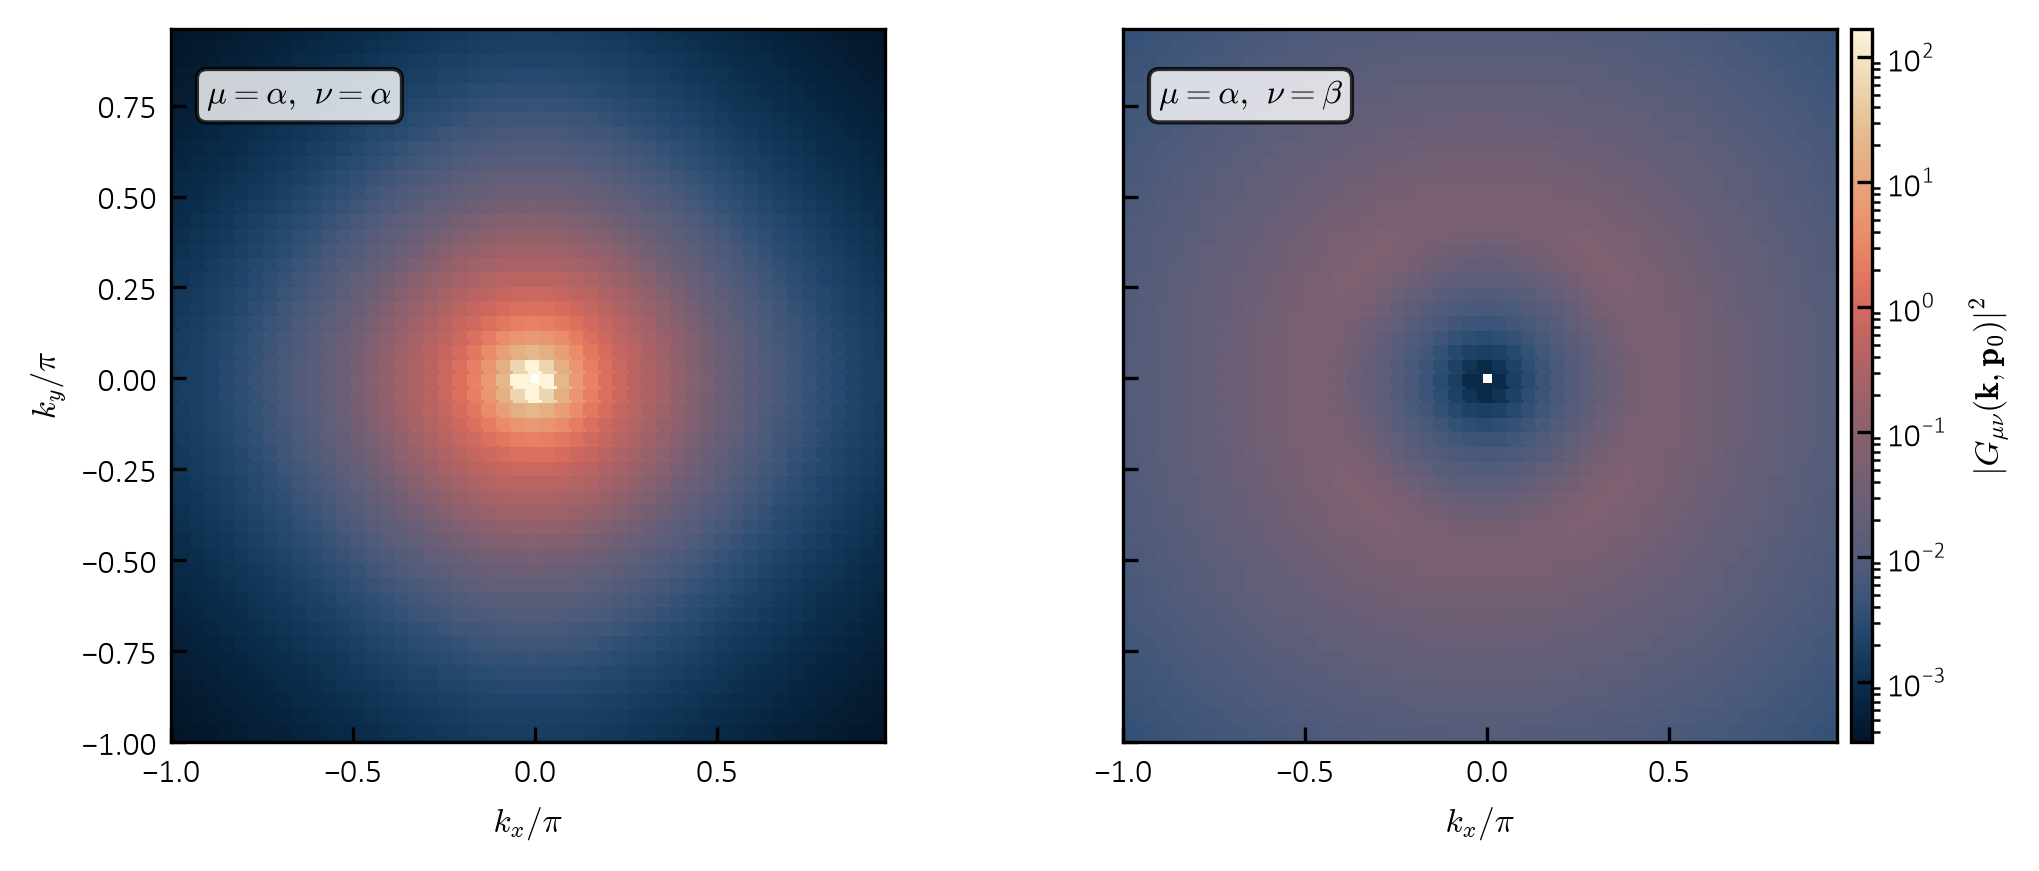

In [560]:
zb = np.abs(gm[:, :, mu]) ** 2    # |G_{mu nu}(k, p0)|^2, shape (N, 2)
zp = zb[zb > 0.0]
norm = LogNorm(vmin=zp.min(), vmax=zp.max())

kx = np.unique(kg[:, 0]) / np.pi
ky = np.unique(kg[:, 1]) / np.pi
bl = (r"\alpha", r"\beta")

with pt.figure(shape=(1, 2), h=0.85, w=2.0, sharex=True, sharey=True) as fg:
    for nu, a in enumerate(fg.ax):
        zz = np.ma.masked_equal(zb[:, nu].reshape(bd.shape).T, 0.0)
        im = color_map(a, kx, ky, zz, norm=norm)
        a.text(0.05, 0.93, rf"$\mu={bl[mu]},\ \nu={bl[nu]}$",
               transform=a.transAxes, ha="left", va="top",
               bbox=dict(boxstyle="round,pad=0.3", fc="white",
                         ec="black", alpha=0.8))
        format_ax(a, x=kx, xlabel=r"$k_x/\pi$", grid=False)
        a.set_aspect("equal")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")
    fg.colorbar(im, r"$|G_{\mu\nu}(\mathbf{k},\mathbf{p}_0)|^2$",
                ax=fg.ax[-1], external=True)

In [561]:


pk = pb.pack(bs)               # static bath data (not "bp": that is your pars dict)
e = np.asarray(st.e)           # (2, N) quasiparticle energies
de = e - e[mu, ip]             # E_{nu k} - E_{mu p0}
w = np.abs(de)
qm = np.linalg.norm(qk, axis=1)

om = pb.omega_q(qm, b)                                    # omega_q, (N,)
sp, sl = pb._line(jnp.asarray(w), om[None, :], b.ew, pk)  # Lorentzian factor

nb = [np.asarray(pb._bose(jnp.asarray(w), c.t)) for c in bs]
fb = sum(np.where(de < 0.0, 1.0 + n, n) for n in nb)      # N1 + N2 + 2 theta(-dE)

lz = np.array(sp)
lz[mu, ip], fb[mu, ip] = np.nan, np.nan                   # self term is excluded

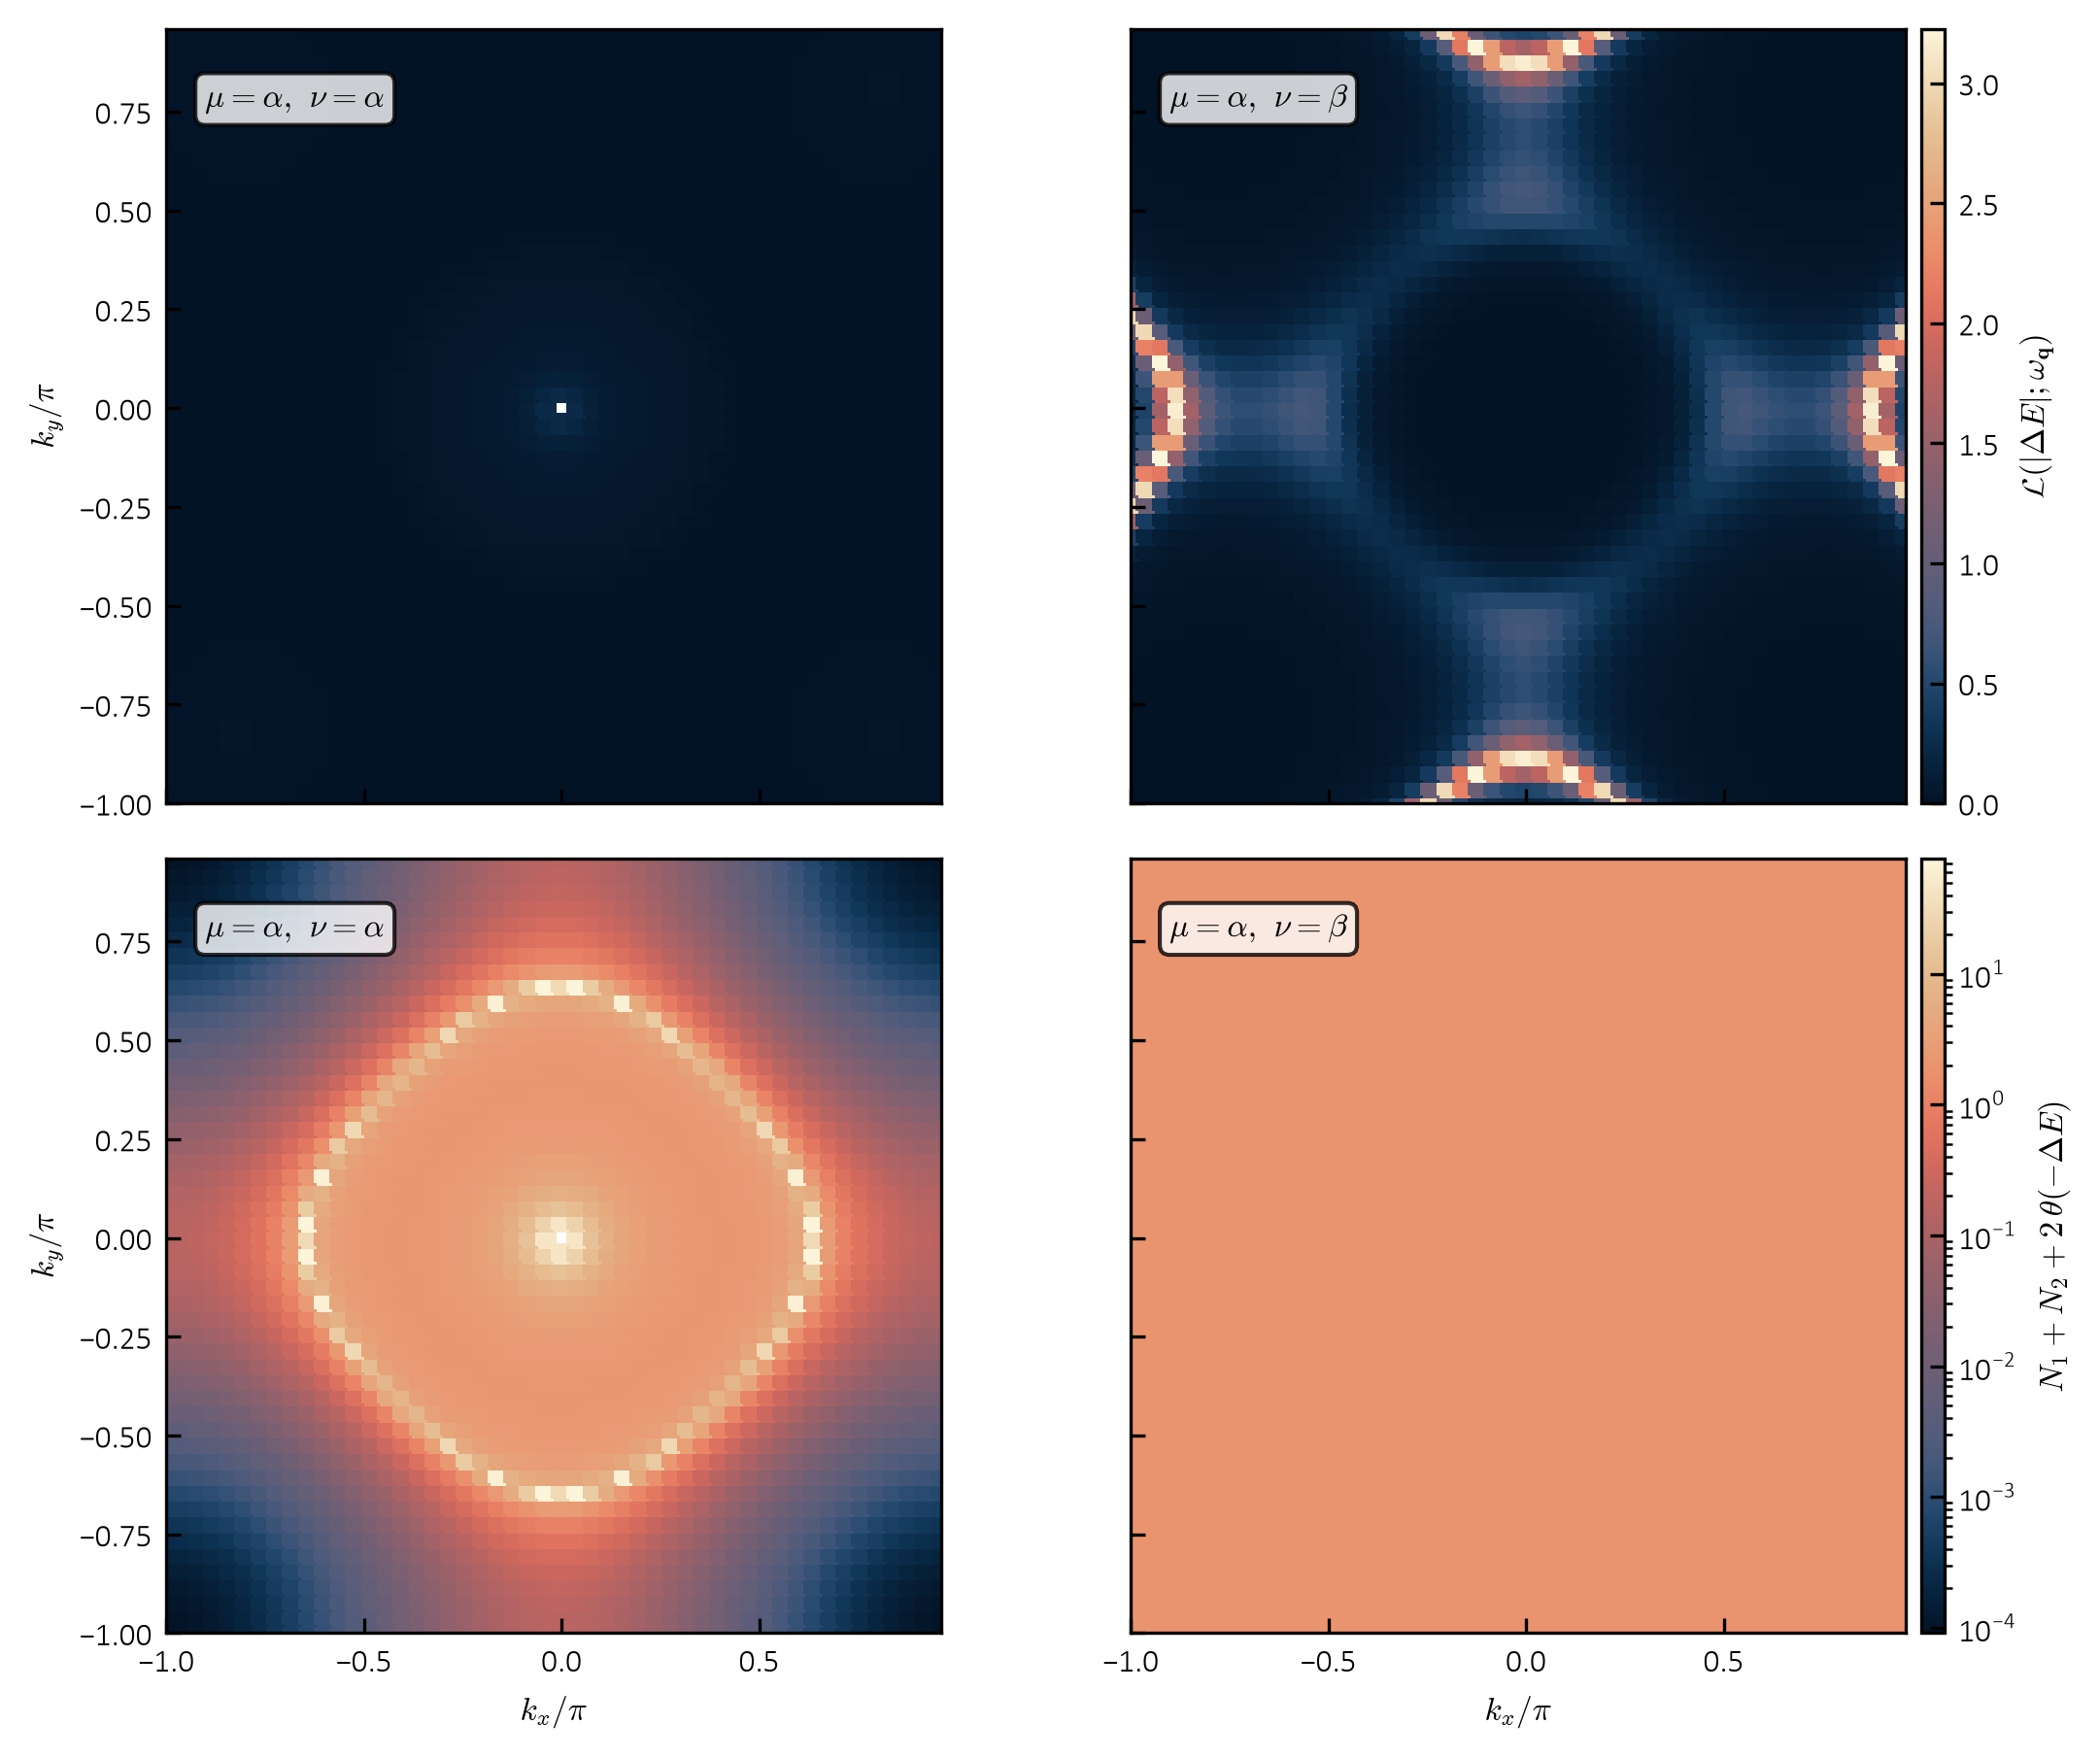

In [562]:
def lnorm(z, dr=1.0e-8):
    """Log norm over positive finite values, floored at dr * max."""
    zp = z[np.isfinite(z) & (z > 0.0)]
    return LogNorm(vmin=max(zp.min(), dr * zp.max()), vmax=zp.max())


def bz_pair(fg, ax, z, norm, lab):
    """Draw the nu = alpha, beta panels of a (2, N) field over the BZ."""
    for nu, a in enumerate(ax):
        zz = np.ma.masked_invalid(z[nu].reshape(bd.shape).T)
        im = color_map(a, kx, ky, zz, norm=norm)
        a.text(0.05, 0.93, rf"$\mu={bl[mu]},\ \nu={bl[nu]}$",
               transform=a.transAxes, ha="left", va="top",
               bbox=dict(boxstyle="round,pad=0.3", fc="white",
                         ec="black", alpha=0.8))
        format_ax(a, x=kx, grid=False)
        a.set_aspect("equal")
    fg.colorbar(im, lab, ax=ax[-1], external=True)


with pt.figure(shape=(2, 2), h=1.7, w=2.0, sharex=True, sharey=True) as fg:
    bz_pair(fg, fg.ax[0], lz, Normalize(0.0, np.nanmax(lz)),
            r"$\mathcal{L}(|\Delta E|;\omega_\mathbf{q})$")
    bz_pair(fg, fg.ax[1], fb, lnorm(fb),
            r"$N_1+N_2+2\,\theta(-\Delta E)$")
    for a in fg.ax[1]:
        a.set_xlabel(r"$k_x/\pi$")
    for a in fg.ax[:, 0]:
        a.set_ylabel(r"$k_y/\pi$")

max rel. diff, factors vs source_rates: 4.67e-16


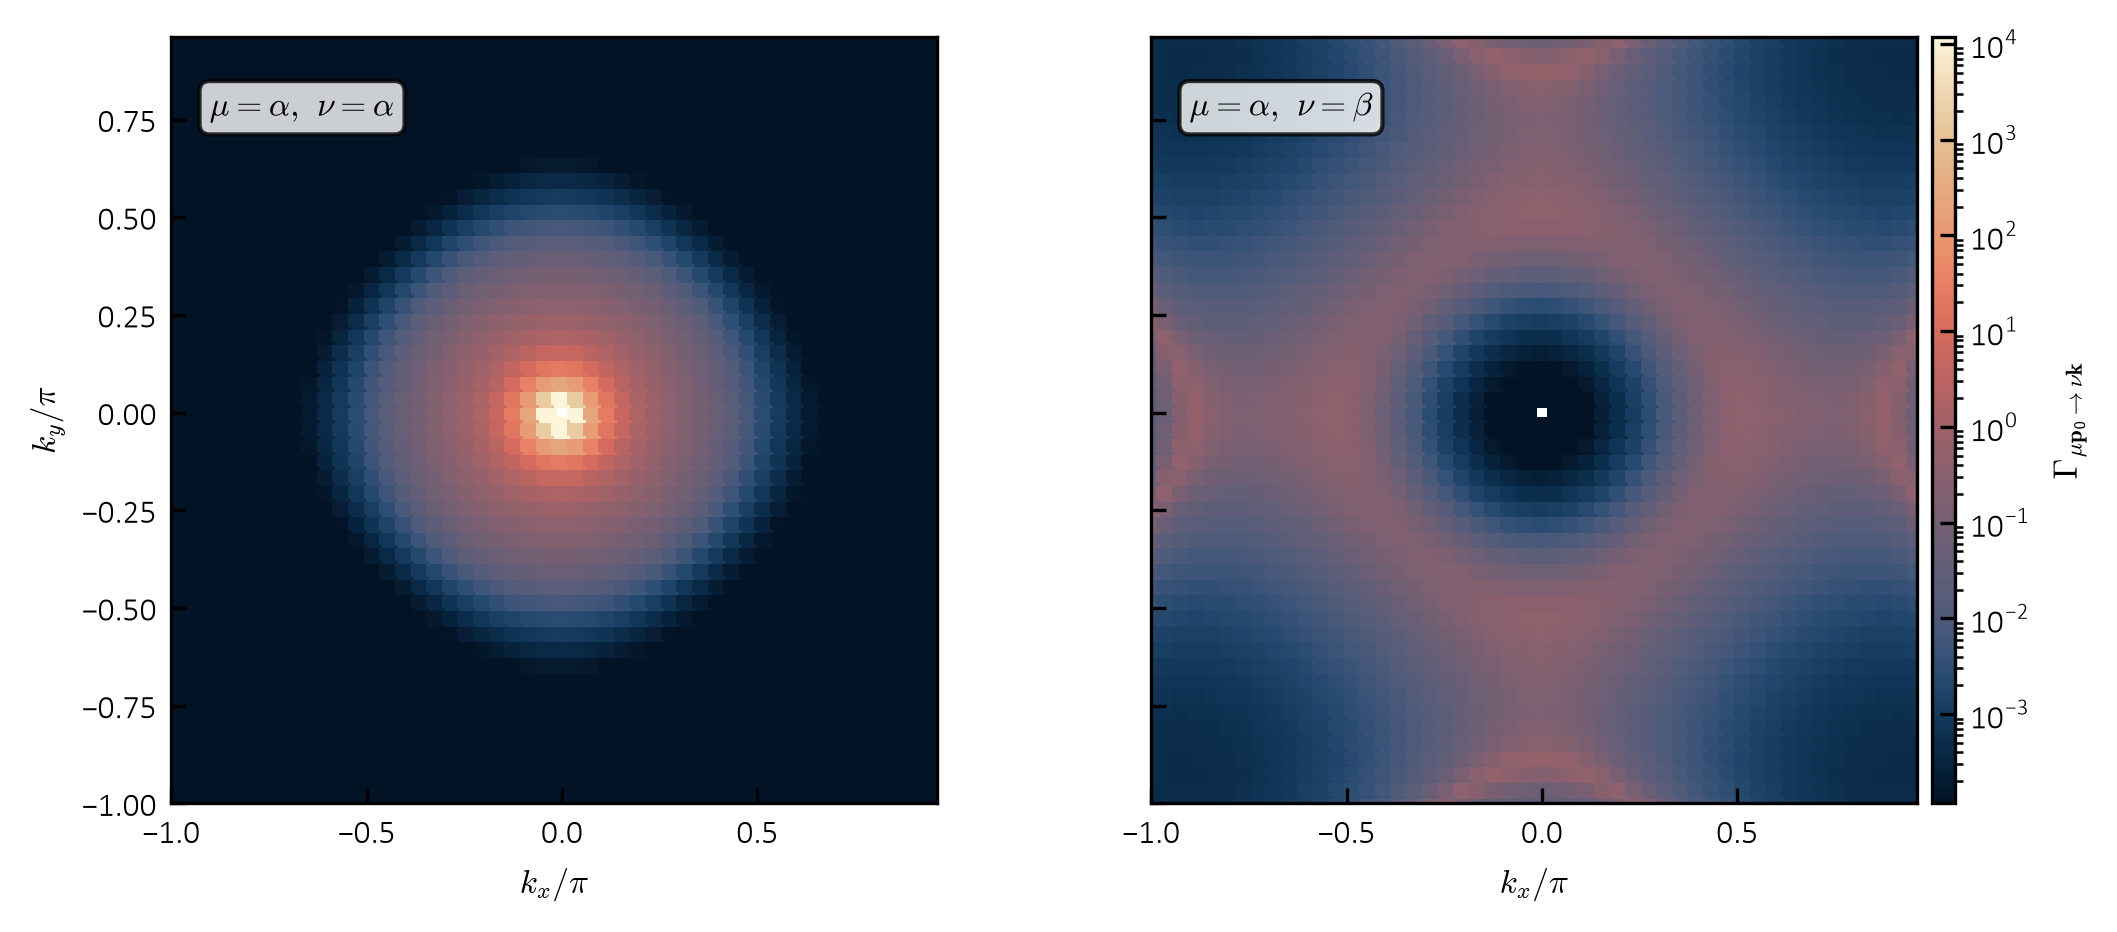

In [563]:
gr = np.asarray(pb.source_rates(st, bs, mu, ip))   # Gamma_{mu p0 -> nu k}, (2, N)

g2 = 2.0 * np.pi * np.abs(gm[:, :, mu]).T ** 2     # 2 pi |G_{mu nu}|^2, (2, N)
th = []
for c in bs:
    ab, em = pb._therm(sp, sl, jnp.asarray(w), c.t)
    th.append(np.where(de < 0.0, em, ab))
gc = g2 * sum(th)
gc[mu, ip] = 0.0

er = np.max(np.abs(gc - gr)) / np.max(np.abs(gr))
print(f"max rel. diff, factors vs source_rates: {er:.2e}")

gp = gr.copy()
gp[mu, ip] = np.nan
with pt.figure(shape=(1, 2), h=0.85, w=2.0, sharex=True, sharey=True) as fg:
    bz_pair(fg, fg.ax, gp, lnorm(gp),
            r"$\Gamma_{\mu\mathbf{p}_0\to\nu\mathbf{k}}$")
    for a in fg.ax:
        a.set_xlabel(r"$k_x/\pi$")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")

In [564]:
ij, x, xt = k_path(bd)                 # Gamma(0,0) -> X(-pi,0) -> M(-pi,-pi) -> Gamma
sh = bd.shape
tl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

ep = take_path(e, ij, sh)              # E_{nu k} on the path, (2, L)
wq = take_path(np.asarray(om), ij, sh) # omega_q, q = k - p0
e0 = e[mu, ip]                         # E_{mu p0}

sf = np.zeros_like(de, dtype=bool)
sf[mu, ip] = True                      # self term, removed by rates()


def on_path(z):
    """Take a (2, N) field onto the path, with the self term as NaN."""
    z = np.where(sf, np.nan, np.asarray(z, dtype=float))
    return take_path(z, ij, sh)

def cross(y, lv):
    """Path positions where y crosses lv (linear interpolation)."""
    d = y - lv
    i = np.where(np.sign(d[:-1]) * np.sign(d[1:]) < 0)[0]
    return x[i] - d[i] * (x[i + 1] - x[i]) / (d[i + 1] - d[i])



yg, yl, yf, yr = (on_path(z) for z in (g2, sp, fb, gr))

/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:509: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout(rect=self.rect)


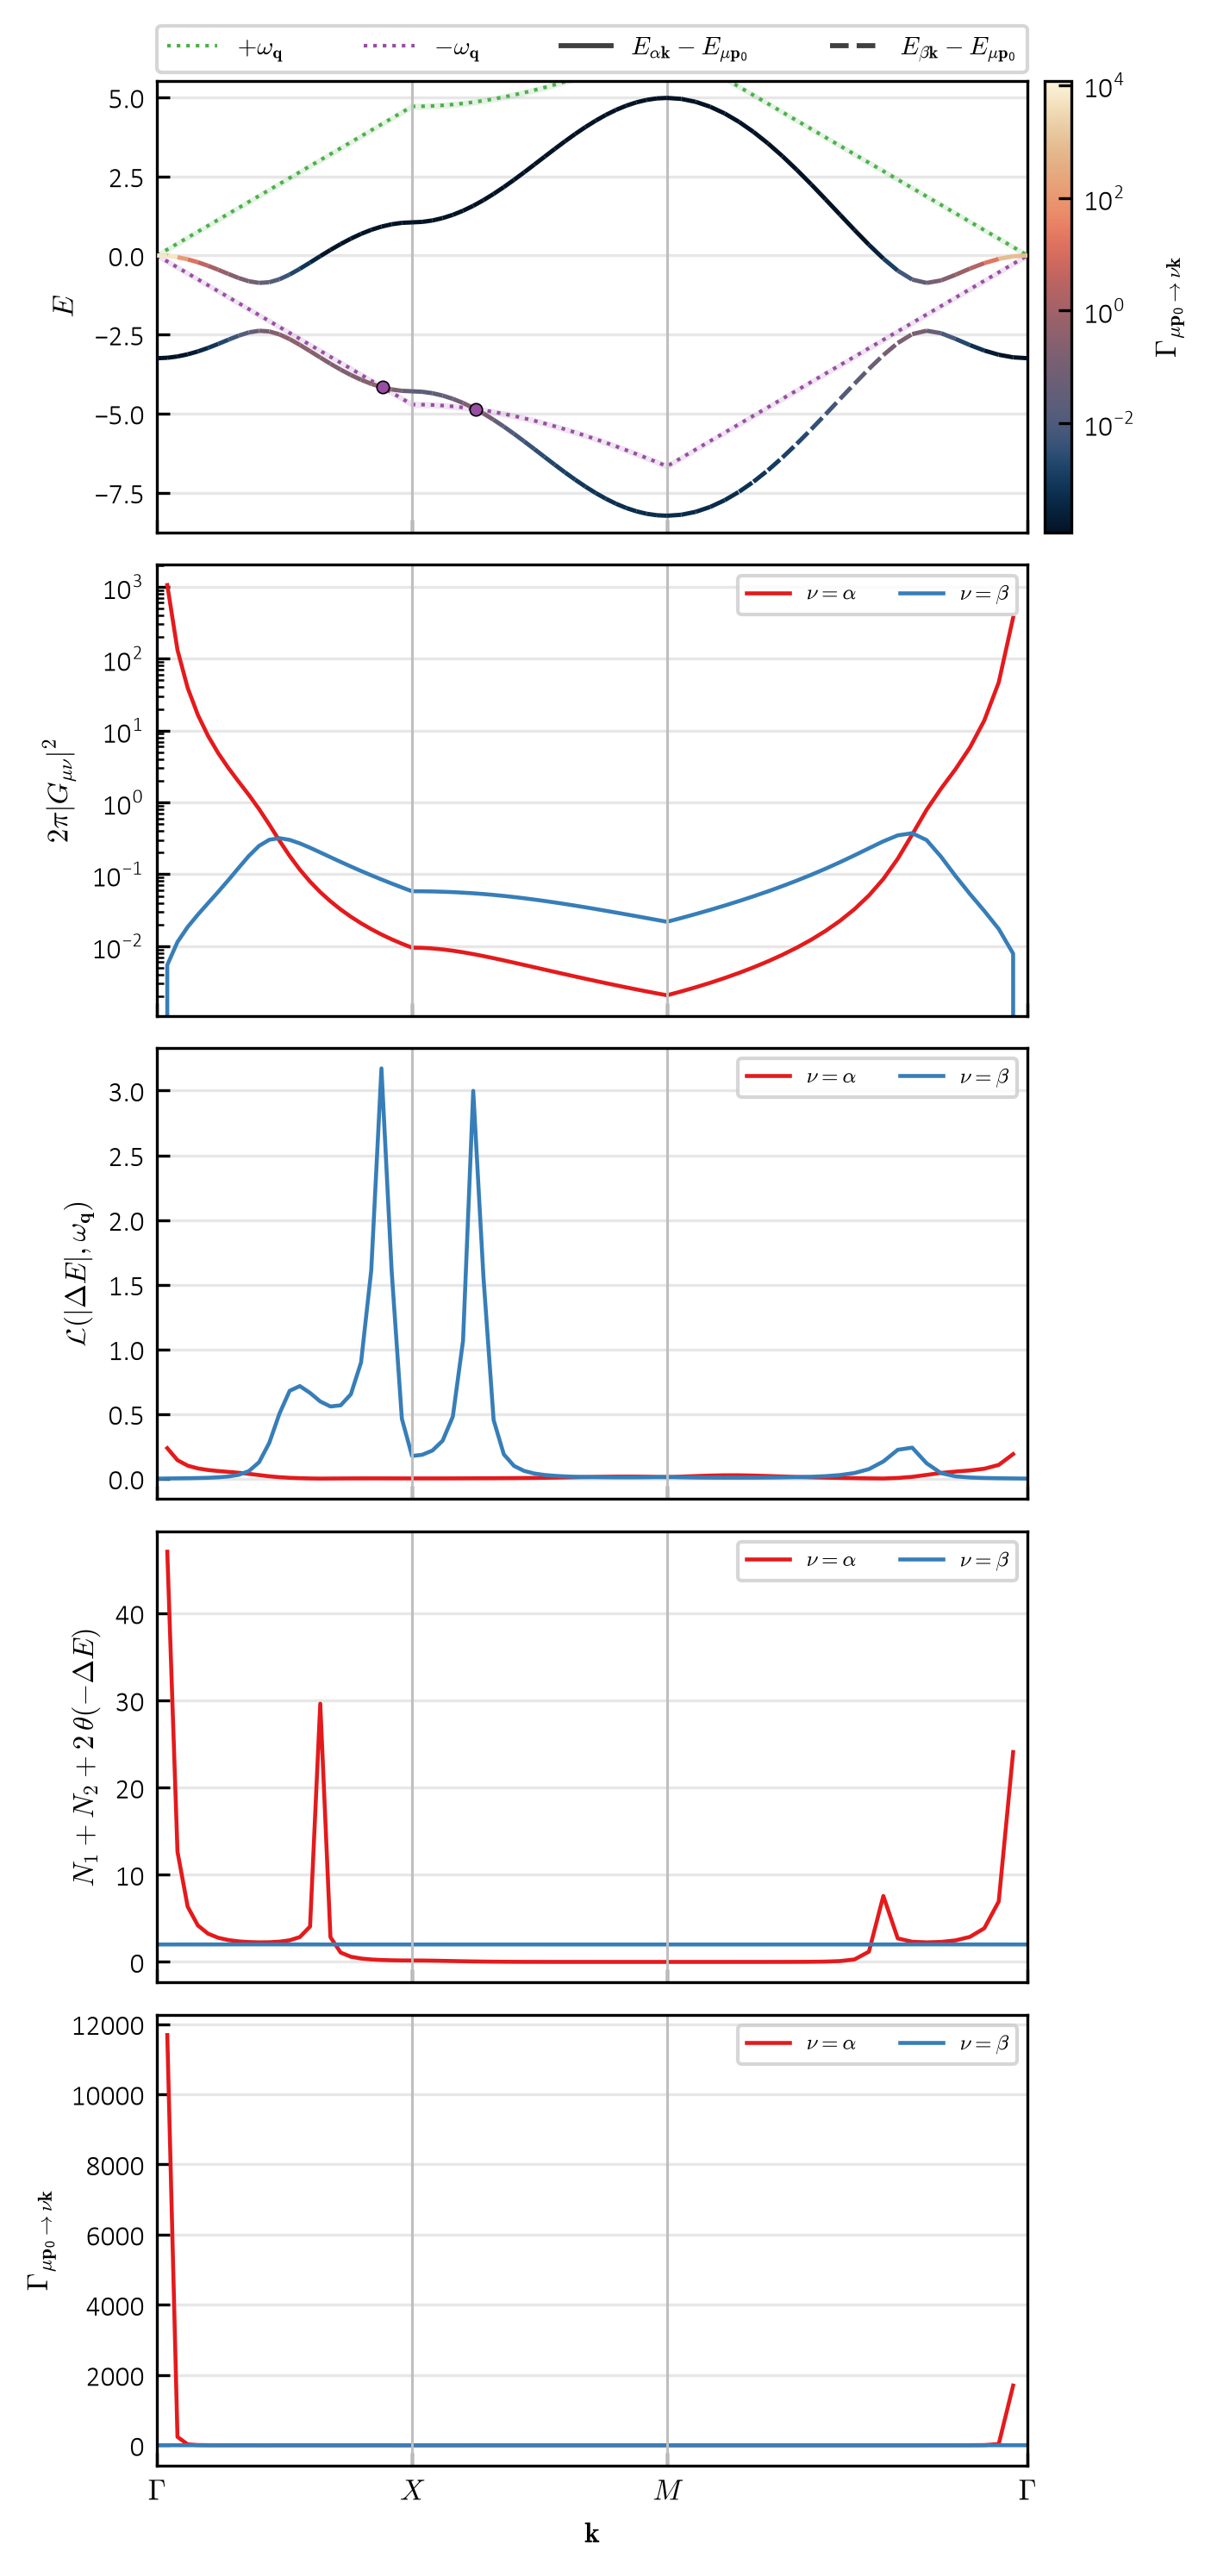

In [565]:
rows = (
    (yg, r"$2\pi|G_{\mu\nu}|^2$", False),
    (yl, r"$\mathcal{L}(|\Delta E|, \omega_\mathbf{q})$", False),
    (yf, r"$N_1+N_2+2\,\theta(-\Delta E)$", True),
    (yr, r"$\Gamma_{\mu\mathbf{p}_0\to\nu\mathbf{k}}$", True),
)
cn = lnorm(gr)

with pt.figure(shape=(5, 1), h=3.0, w=1.2, sharex=True) as fg:
    a = fg.ax[0]
    for s, cl in ((1.0, SET1_LIST[2]), (-1.0, SET1_LIST[3])):
        a.fill_between(x, s * wq - b.ew, s * wq + b.ew,
                       color=cl, alpha=0.15, lw=0)
        a.plot(x, s * wq, color=cl, ls=":", lw=1.0,
               label=rf"${'+' if s > 0 else '-'}\omega_\mathbf{{q}}$")
        for nu in range(len(ep)):
            xc = cross(ep[nu] - e0,  s * wq)
            a.scatter(xc, np.interp(xc, x,  s * wq), color=cl, s=12,
                              edgecolors="k", linewidths=0.4, zorder=6)
    for nu, ls in enumerate(("-", "--")):
        c = np.nan_to_num(yr[nu], nan=cn.vmin)
        lc = color_line(a, x, ep[nu] - e0, c, np.full_like(x, 0.4),
                        cmaps.lipari, cn, ls=ls,
                        label=rf"$E_{{{bl[nu]}\mathbf{{k}}}} - E_{{\mu\mathbf{{p}}_0}}$")
    yy = ep.ravel() - e0
    dy = 0.04 * np.ptp(yy)
    format_ax(a, x=x, ylabel=r"$E$", ylim=(yy.min() - dy, yy.max() + dy),
              xticks=xt)
    add_legend(a, top=True, ncol=4, fontsize=7)
    fg.colorbar(lc, r"$\Gamma_{\mu\mathbf{p}_0\to\nu\mathbf{k}}$",
                ax=a, external=True)
    fg.ax[1].set_yscale("log")

    for a, (y, lab, lg) in zip(fg.ax[1:], rows):
        for nu in range(2):
            a.plot(x, y[nu], color=SET1_LIST[nu], lw=1.1,
                   label=rf"$\nu={bl[nu]}$")
        # if lg:
        #     a.set_ylim(1.0e-8 * np.nanmax(y), 2.0 * np.nanmax(y))
        format_ax(a, x=x, ylabel=lab, xticks=xt)
        add_legend(a, ncol=2, fontsize=6)
    
    for a in fg.ax:
        a.axvline(xt[1], color="0.75", lw=0.7)
        a.axvline(xt[2], color="0.75", lw=0.7)
    fg.ax[-1].set_xticklabels(tl)
    fg.ax[-1].set_xlabel(r"$\mathbf{k}$")
    fg.layout((0, 0, 1, 0.96))

In [566]:
ef = e.reshape(-1)                        # flat (alpha k, beta k) energies

for c in bs:
    r = np.asarray(pb.rates(st, pb.pack((c,))))    # R[dest, src], one bath
    ok = (r > 1e-12 * r.max()) & (r.T > 1e-12 * r.max())
    lr = np.log(r[ok] / r.T[ok])                   # log(R_ij / R_ji)
    ex = -(ef[:, None] - ef[None, :])[ok] / c.t    # -(E_i - E_j) / T
    print(c.name, "max detailed-balance error:", np.max(np.abs(lr - ex)))

bath_1 max detailed-balance error: 2.842170943040401e-14
bath_1 max detailed-balance error: 2.1760371282653068e-14


In [ ]:
import dataclasses
import EI.eff_T as et

et.ej = ej      # route eff_T through ei_jax_2 in this kernel

mc = 0.0        # chemical potential; ei_jax_2 energies already carry -V/2
ep = {
    "dt": 0.5, "mix": [0.5, 0.5], "tol": 1.0e-5,
    "nmax": 2000, "chk": 10, "mf": False, "prog": True,
    "mode": "block", "block": 512,
}


sf = solve_teff(bd, p, bs, so, t1, t2, mc, op, ep)
sf = dataclasses.replace(sf, st=so.st)   # same d, m since mf=False

logger.info("Delta = %.6f, m = %.6f", so.d, so.m)
logger.info("T_eff/T_c = %.6f, power = %.3e, ok = %s",
            sf.t / tc, sf.power, sf.ok)


Effective temperature:   0%|          | 0/2000 [00:00<?, ?it/s]

[17:31:52] [INFO    ] Delta = 0.755052, m = -0.709781
[17:31:52] [INFO    ] T_eff/T_c = 0.634390, power = 2.806e-07, ok = True


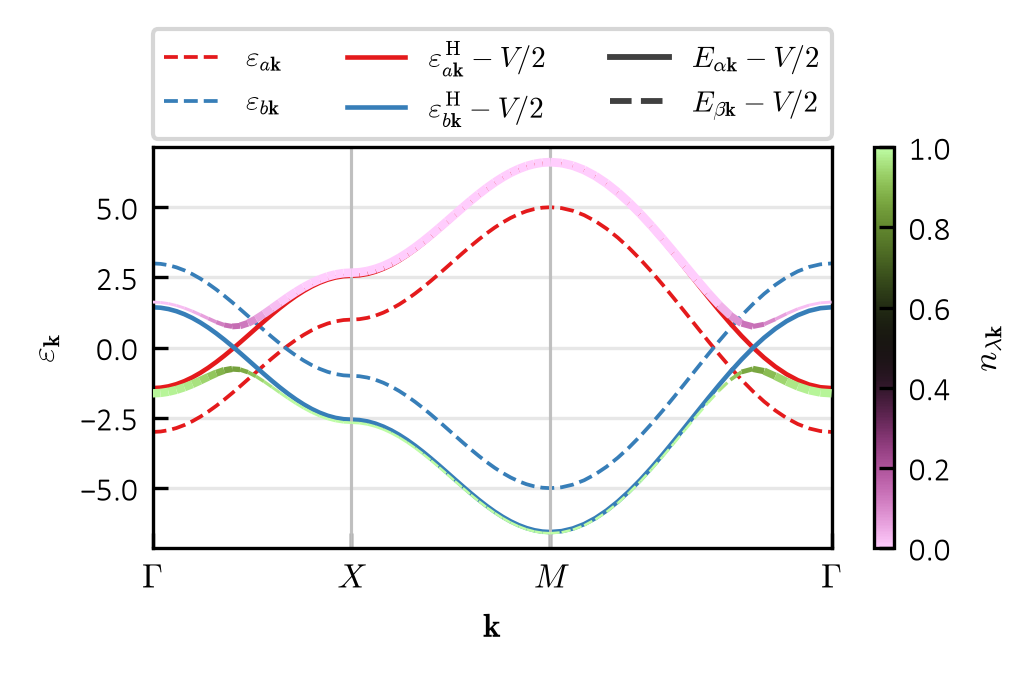

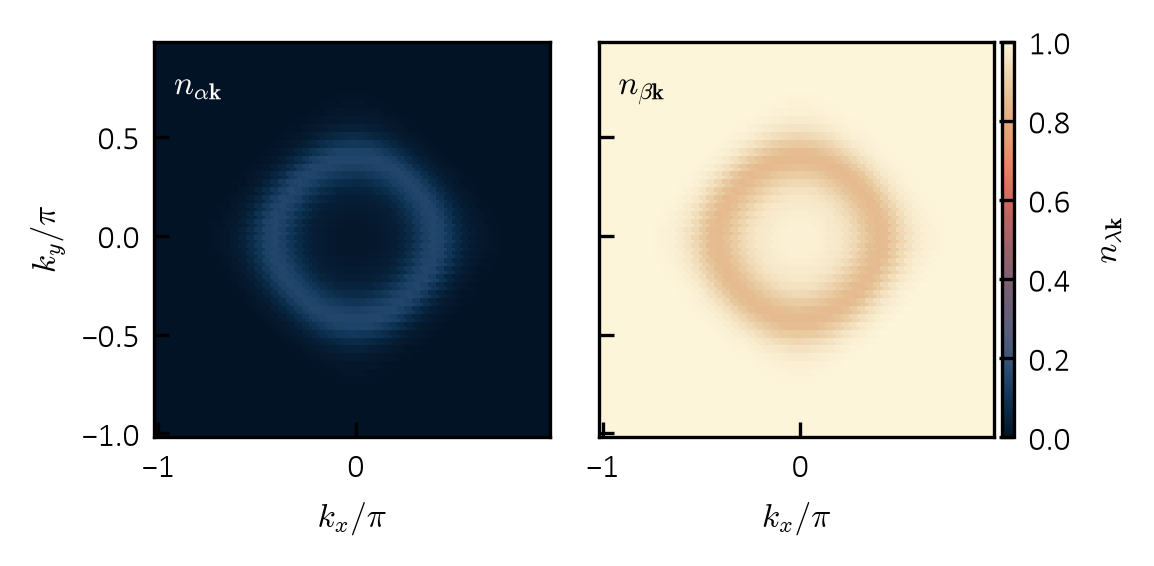

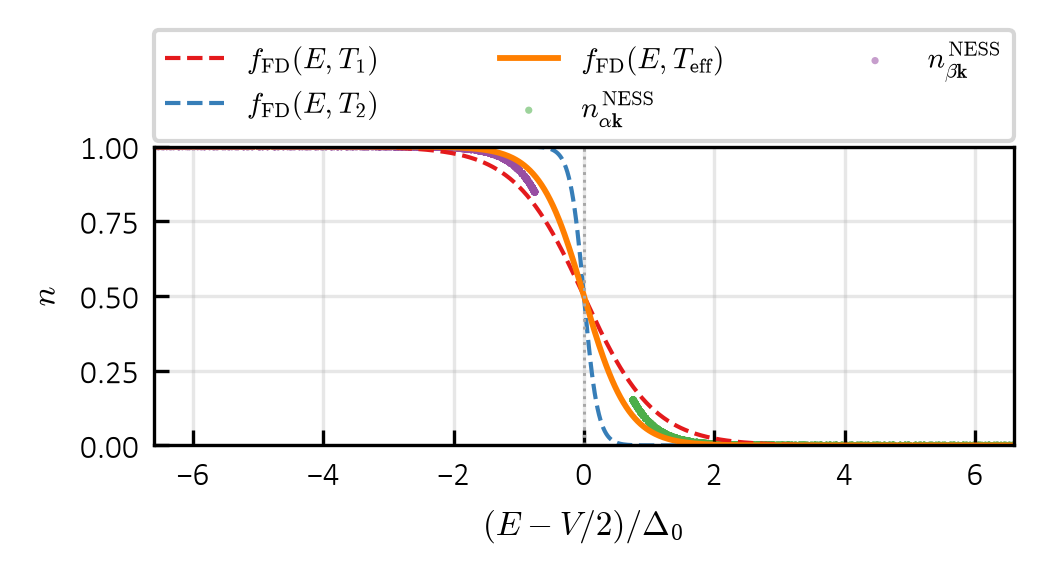

AttributeError: 'float' object has no attribute 'st'

In [ ]:
plot_dispersion(pt, bd, so, mc)                 # bands on Gamma-X-M, coloured by n
plot_bz(pt, bd, so)                             # 2D n_alpha, n_beta
plot_energy(pt, so, sf, t1, t2, mc, d0)         # n vs E against FD at T1, T2, T_eff
plot_xi(pt, bd, p, eq, so, sf, t1, t2, d0)      # n vs |xi| against FD at T1, T2, T_eff

In [569]:
w0 = bs[0].w0
nm = 0.5 * sum(1.0 / np.expm1(w0 / c.t) for c in bs)   # N_bar(omega_0)
ts = w0 / np.log1p(1.0 / nm)                           # T* from the ratio
print(f"T*/Tc = {ts / tc:.4f},  T_eff/Tc = {sf.t / tc:.4f},  Delta = {so.d:.2e}")

T*/Tc = 0.8715,  T_eff/Tc = 0.6344,  Delta = 7.55e-01


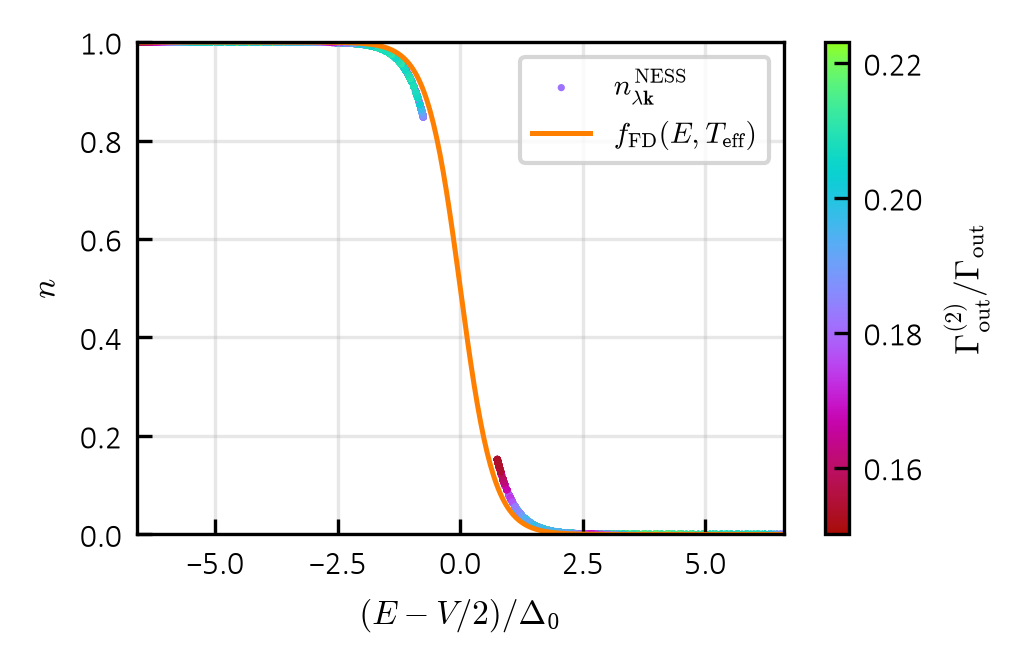

In [570]:
ef = np.asarray(st.e).reshape(-1)                       # (alpha k, beta k) energies
ro = [np.asarray(pb.rates(st, pb.pack((c,)))).sum(axis=0) for c in bs]
hf = ro[1] / (ro[0] + ro[1])                            # hot share of out-scattering
nn = np.asarray(so.n).reshape(-1)
xs = np.linspace(ef.min(), ef.max(), 400) / d0

with pt.figure(h=0.65) as fg:
    a = fg.ax
    im = a.scatter(ef / d0, nn, c=hf, s=3, cmap=cmaps.neon,
                   edgecolors="none", label=r"$n_{\lambda\mathbf{k}}^{\mathrm{NESS}}$")
    a.plot(xs, 1.0 / (np.exp(sf.beta * xs * d0) + 1.0), color=SET1_LIST[4],
           lw=1.2, label=r"$f_{\mathrm{FD}}(E,T_{\mathrm{eff}})$")
    format_ax(a, x=xs, xlabel=r"$(E-V/2)/\Delta_0$", ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, fontsize=7)
    fg.colorbar(im, r"$\Gamma^{(2)}_{\mathrm{out}}/\Gamma_{\mathrm{out}}$", ax=a)

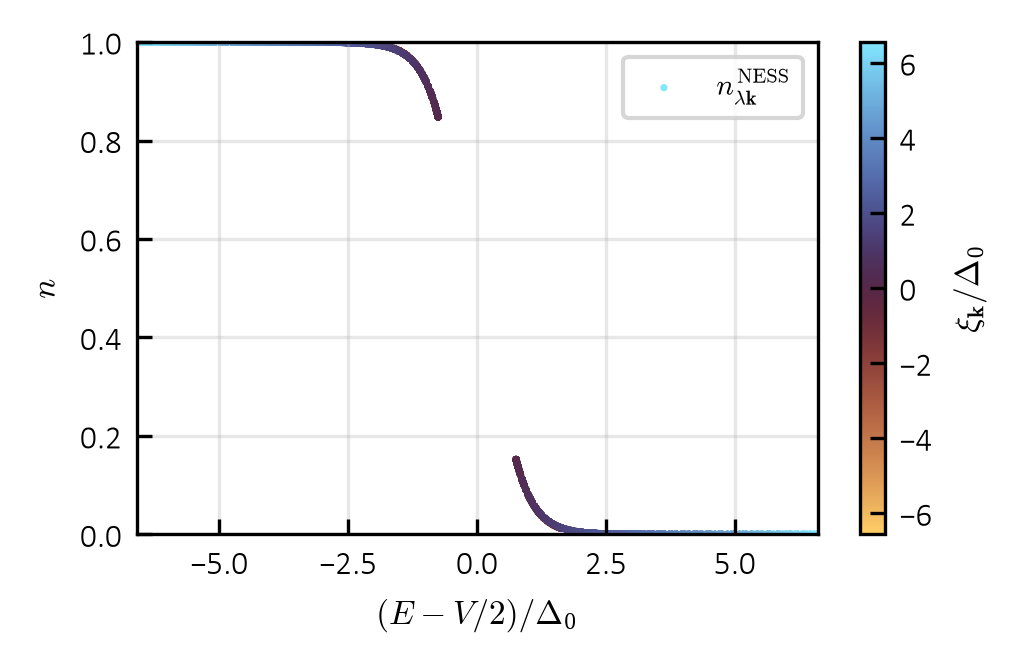

In [571]:
xi = 0.5 * (np.asarray(so.st.eah) - np.asarray(so.st.ebh))
xs2 = np.tile(xi, 2) / d0                       # same xi for both bands
lim = np.abs(xs2).max()
with pt.figure(h=0.65) as fg:
    a = fg.ax
    im = a.scatter(ef / d0, nn, c=xs2, s=3, cmap=cmaps.managua, vmin=-lim, vmax=lim,
                   edgecolors="none", label=r"$n_{\lambda\mathbf{k}}^{\mathrm{NESS}}$")
    format_ax(a, x=xs, xlabel=r"$(E-V/2)/\Delta_0$", ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, fontsize=7)
    fg.colorbar(im, r"$\xi_\mathbf{k}/\Delta_0$", ax=a)

In [572]:
for lam, lb in enumerate(("alpha", "beta")):
    x, y = np.asarray(st.e[lam]), np.asarray(so.n[lam])
    ok = (y > 0.05) & (y < 0.95)
    sl, ic = np.polyfit(x[ok], np.log(1.0 / y[ok] - 1.0), 1)
    print(f"{lb}: T/Tc = {1.0 / sl / tc:.3f}, mu/D0 = {-ic / sl / d0:.3f}")

alpha: T/Tc = 0.616, mu/D0 = 0.188
beta: T/Tc = 0.616, mu/D0 = -0.188


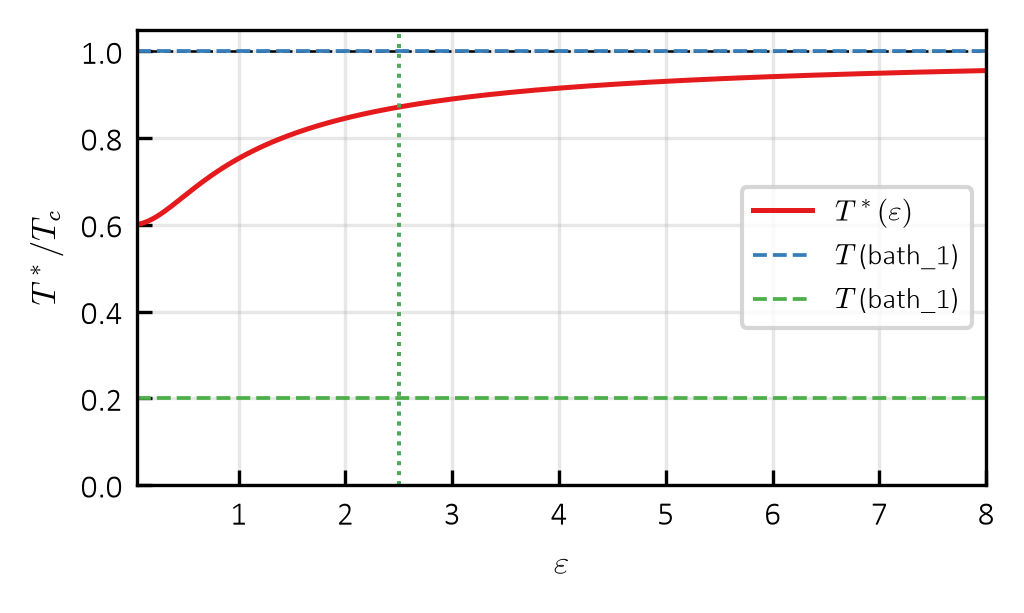

In [573]:
eg = np.linspace(0.05, 8.0, 400)          # energy transfer grid
dn, up = 0.0, 0.0
for c in bs:
    a = np.asarray(pb._spec_e(jnp.asarray(eg), c.w0, c.ew)) * c.amp / c.w0
    n = np.asarray(pb._bose(jnp.asarray(eg), c.t))
    dn, up = dn + a * (1.0 + n), up + a * n
tsf = eg / np.log(dn / up)                # T*(eps)

with pt.figure(h=0.6) as fg:
    a = fg.ax
    a.plot(eg, tsf / tc, color=SET1_LIST[0], lw=1.2, label=r"$T^*(\varepsilon)$")
    # a.plot(eg, t1n / (1 + t1n * np.log(1 + bs[1].w0 / bs[0].w0) / eg))
    a.plot(eg, np.ones_like(eg), color="k", ls="--", lw=0.6)
    for c, cl in zip(bs, SET1_LIST[1:3]):
        a.axhline(c.t / tc, color=cl, ls="--", lw=0.9, label=rf"$T$ ({c.name})")
        a.axvline(c.w0, color=cl, ls=":", lw=0.9)
    format_ax(a, x=eg, xlabel=r"$\varepsilon$", ylabel=r"$T^*/T_c$")
    add_legend(a, ncol=1, fontsize=7)
    a.set_ylim(0, t1n*1.05)

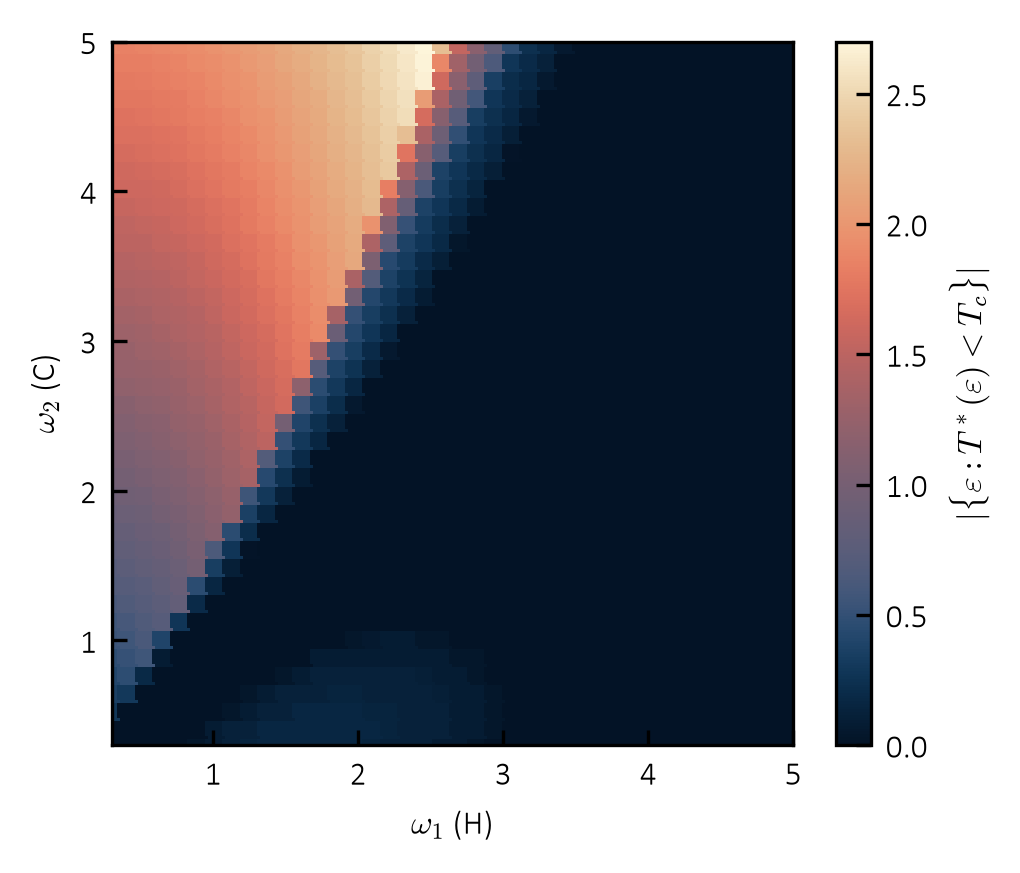

In [574]:
def nbar(eg, bath):
    """Weighted occupation N_bar(eps); bath = [(w0, ew, amp, t), ...]."""
    eg = jnp.asarray(eg)
    a = [pb._spec_e(eg, w0, ew) * amp / w0 for w0, ew, amp, _ in bath]
    n = [pb._bose(eg, t) for *_, t in bath]
    return np.asarray(sum(x * y for x, y in zip(a, n)) / sum(a))


def tstar(eg, bath):
    """T*(eps) = eps / ln(1 + 1/N_bar)."""
    with np.errstate(divide="ignore"):
        return eg / np.log1p(1.0 / nbar(eg, bath))


eg = np.linspace(0.05, 8.0, 400)
wa = np.linspace(0.3, 5.0, 40)              # omega grid for both baths
ew, amp = bs[0].ew, bs[0].amp
tlo, thi = 0.2 * tc, 6.4 * tc               # cold, hot

wd = np.empty((wa.size, wa.size))           # rows omega_2 (hot), cols omega_1 (cold)
for i, w2 in enumerate(wa):
    for j, w1 in enumerate(wa):
        ts = tstar(eg, [(w1, ew, amp, tlo), (w2, ew, amp, thi)])
        wd[i, j] = np.trapezoid((ts < tc).astype(float), eg)

with pt.figure(h=0.85) as fg:
    im = color_map(fg.ax, wa, wa, wd)
    format_ax(fg.ax, x=wa, xlabel=r"$\omega_1$ (H)", ylabel=r"$\omega_2$ (C)", grid=False)
    fg.colorbar(im, r"$|\{\varepsilon : T^*(\varepsilon) < T_c\}|$", ax=fg.ax)